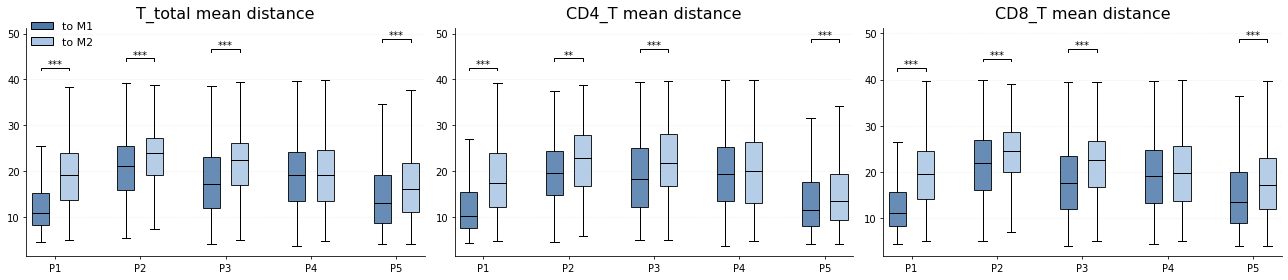

In [13]:
# -*- coding: utf-8 -*-
# Mean distance comparison: Hub(M1) vs Hub(M2)
# JCC-style figure with significance + internal legend

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from scipy.spatial import cKDTree
from matplotlib.patches import Patch

# ===================== PARAMS =====================
file_path = r"C:/Users/Li Chujia/Desktop/cell_annotationV2/annotated_cells_mixed.csv"
RADIUS = 40.0

stage_labels = {"T005":"P1","T006":"P2","T001":"P3","T002":"P4","T004":"P5"}
stages = ["T005","T006","T001","T002","T004"]

HUB_TYPES = ["M1","M2"]
CD4_NAME = "CD4_T"
CD8_NAME = "CD8_T"

COL_ROI = "ROI"
COL_CELLID = "CellID"
COL_X = "X_position"
COL_Y = "Y_position"
COL_TYPE = "cell_type"

metric_list = [
    ("T_total_distmean", "T_total mean distance"),
    ("CD4_T_distmean", "CD4_T mean distance"),
    ("CD8_T_distmean", "CD8_T mean distance"),
]

# ===================== JCC STYLE =====================
def apply_jcc_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)
    ax.tick_params(axis="both", direction="out", length=3, width=0.8)
    ax.grid(axis="y", linestyle=":", alpha=0.25)

def p_to_star(p):
    if p < 0.001: return "***"
    if p < 0.01: return "**"
    if p < 0.05: return "*"
    return ""

def add_sig(ax, x1, x2, y, h, star):
    ax.plot([x1, x1, x2, x2], [y, y+h*0.3, y+h*0.3, y], lw=1, color="black")
    ax.text((x1+x2)/2, y+h*0.35, star, ha="center", fontsize=10)

# ===================== COLORS =====================
jcc_colors = {
    "M1": "#4C78A8",   # deep blue
    "M2": "#A9C5E5"    # light blue
}

# ===================== LOAD =====================
df = pd.read_csv(file_path, encoding="gbk")
df["Stage"] = df[COL_ROI].str.extract(r"(T\d{3})")
df = df[df["Stage"].isin(stages)].copy()

def extract_roi(x):
    m = re.search(r"ROI\D*(\d{1,3})", str(x))
    return f"{int(m.group(1)):03d}" if m else None

df["ROI_num3"] = df[COL_ROI].apply(extract_roi)

# ===================== CORE =====================
rows = []

for roi, g in df.groupby(COL_ROI):
    stage = g["Stage"].iloc[0]
    coords = g[[COL_X, COL_Y]].to_numpy()
    types = g[COL_TYPE].to_numpy()
    cellids = g[COL_CELLID].to_numpy()

    for hub_type in HUB_TYPES:
        mask = (types == hub_type)
        if mask.sum() == 0:
            continue

        hub_coords = coords[mask]
        hub_ids = cellids[mask]
        tree = cKDTree(hub_coords)

        nonhub_idx = np.where(~mask)[0]
        if len(nonhub_idx) == 0:
            continue

        dists, nn = tree.query(coords[nonhub_idx], k=1)
        within = dists <= RADIUS
        if within.sum() == 0:
            continue

        use_idx = nonhub_idx[within]
        assigned = nn[within]

        tmp = pd.DataFrame({
            "hub_local": assigned,
            "dist": dists[within],
            "type": types[use_idx]
        })

        for i, hid in enumerate(hub_ids):
            sub = tmp[tmp["hub_local"] == i]
            if len(sub) == 0:
                continue

            cd4 = sub["type"] == CD4_NAME
            cd8 = sub["type"] == CD8_NAME
            ttot = cd4 | cd8

            rows.append({
                "Stage": stage,
                "Hub": hub_type,
                "T_total_distmean": sub.loc[ttot, "dist"].mean() if ttot.any() else np.nan,
                "CD4_T_distmean": sub.loc[cd4, "dist"].mean() if cd4.any() else np.nan,
                "CD8_T_distmean": sub.loc[cd8, "dist"].mean() if cd8.any() else np.nan,
            })

data = pd.DataFrame(rows)

# ===================== FIGURE =====================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

pos_map = {}
x_ticks = []
p = 1

for st in stages:
    pos_map[(st,"M1")] = p
    pos_map[(st,"M2")] = p+1
    x_ticks.append((p+p+1)/2)
    p += 3

for ax, (metric, title) in zip(axes, metric_list):

    box_data = []
    box_pos = []
    sig_list = []

    for st in stages:
        v1 = data[(data["Stage"]==st)&(data["Hub"]=="M1")][metric].dropna()
        v2 = data[(data["Stage"]==st)&(data["Hub"]=="M2")][metric].dropna()

        box_data.append(v1.values)
        box_data.append(v2.values)

        box_pos.append(pos_map[(st,"M1")])
        box_pos.append(pos_map[(st,"M2")])

        if len(v1)>0 and len(v2)>0:
            _, pval = mannwhitneyu(v1, v2)
        else:
            pval = np.nan

        sig_list.append((st, pval))

    bp = ax.boxplot(
        box_data,
        positions=box_pos,
        widths=0.6,
        patch_artist=True,
        showfliers=False
    )

    # ===== COLORS =====
    for i, b in enumerate(bp["boxes"]):
        if i % 2 == 0:
            b.set_facecolor(jcc_colors["M1"])
        else:
            b.set_facecolor(jcc_colors["M2"])
        b.set_edgecolor("black")
        b.set_alpha(0.85)

    for k in ["whiskers","caps","medians"]:
        for item in bp[k]:
            item.set_color("black")
            item.set_linewidth(1)

    apply_jcc_axis(ax)

    ax.set_title(title, fontsize=16, pad=10)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels([stage_labels[s] for s in stages])

    # ===== SIGNIFICANCE =====
    allv = data[metric].dropna()
    y_base = float(allv.max()) if len(allv)>0 else 1
    h = y_base * 0.05

    for st, pval in sig_list:
        if not np.isfinite(pval):
            continue
        star = p_to_star(pval)
        if star == "":
            continue

        x1 = pos_map[(st,"M1")]
        x2 = pos_map[(st,"M2")]

        add_sig(ax, x1, x2, y_base+h, h, star)
        y_base *= 1.05

# ===================== INTERNAL LEGEND =====================
legend_handles = [
    Patch(facecolor=jcc_colors["M1"], edgecolor="black", label="to M1"),
    Patch(facecolor=jcc_colors["M2"], edgecolor="black", label="to M2"),
]

# 放在第一个子图内部（不占右侧空间）
axes[0].legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(0.0, 1.05),
    frameon=False,
    fontsize=11,
    borderaxespad=0
)
# ===================== SAVE =====================
plt.tight_layout()

plt.savefig(
    "Fig3d_M1_M2_mean_distance_JCC.tiff",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.savefig(
    "Fig3d_M1_M2_mean_distance_JCC.pdf",
    bbox_inches="tight",
    facecolor="white"
)

plt.show()